In [1]:
# 1. Cargar archivos necesarios del dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Postings
df_postings = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arshkon/linkedin-job-postings",
    "postings.csv"
)

# Industrias por job posting (la "etiqueta" que vas a predecir vive acá)
df_job_industries = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arshkon/linkedin-job-postings",
    "jobs/job_industries.csv"
)

# Diccionario de industrias (id -> nombre legible)
df_industries = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "arshkon/linkedin-job-postings",
    "mappings/industries.csv"
)

print("postings:", df_postings.shape)
print("job_industries:", df_job_industries.shape)
print("industries:", df_industries.shape)

/tmp/ipykernel_13664/3696204378.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_postings = kagglehub.load_dataset(


Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


/tmp/ipykernel_13664/3696204378.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_job_industries = kagglehub.load_dataset(


Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


/tmp/ipykernel_13664/3696204378.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_industries = kagglehub.load_dataset(


Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
postings: (123849, 31)
job_industries: (164808, 2)
industries: (422, 2)


In [2]:
# 2. Construir el dataset etiquetado
# Un job_id puede tener múltiples industrias asociadas.
# Para la primera iteración: quedarse con la primera industria por job

df_job_ind = (
    df_job_industries
    .drop_duplicates(subset="job_id", keep="first")
    .merge(df_industries, on="industry_id", how="left")
)

df = df_postings.merge(df_job_ind[["job_id", "industry_name"]], on="job_id", how="inner")

# Columnas mínimas para arrancar el clasificador
df = df[["job_id", "title", "description", "industry_name"]].dropna(subset=["description", "industry_name"])

print(df.shape)
print(df["industry_name"].value_counts().head(20))

(122308, 4)
industry_name
Hospitals and Health Care             16214
Retail                                 8736
Staffing and Recruiting                8085
IT Services and IT Consulting          7964
Financial Services                     5976
Software Development                   4107
Construction                           2670
Manufacturing                          2479
Real Estate                            2090
Banking                                2002
Hospitality                            1909
Insurance                              1850
Motor Vehicle Manufacturing            1686
Pharmaceutical Manufacturing           1635
Industrial Machinery Manufacturing     1595
Higher Education                       1561
Telecommunications                     1559
Advertising Services                   1458
Accounting                             1431
Government Administration              1402
Name: count, dtype: int64


In [3]:
# 3. Mapeo a macro-categorías
# Mapeo curado a partir de las industrias granulares de LinkedIn.
# La idea: agrupar por afinidad de skills/perfiles, no por sector económico puro,
# porque al final el clasificador y el agente trabajan sobre descripciones de cargo.

macro_map = {
    # IT & Software
    "IT Services and IT Consulting": "IT & Software",
    "Software Development": "IT & Software",
    "Computer and Network Security": "IT & Software",
    "Computer Hardware Manufacturing": "IT & Software",
    "Computer Networking Products": "IT & Software",
    "Data Infrastructure and Analytics": "IT & Software",
    "Internet Publishing": "IT & Software",
    "Technology, Information and Internet": "IT & Software",
    "Telecommunications": "IT & Software",

    # Finance
    "Financial Services": "Finance",
    "Banking": "Finance",
    "Insurance": "Finance",
    "Investment Banking": "Finance",
    "Investment Management": "Finance",
    "Venture Capital and Private Equity Principals": "Finance",
    "Capital Markets": "Finance",
    "Accounting": "Finance",

    # Healthcare
    "Hospitals and Health Care": "Healthcare",
    "Medical Practices": "Healthcare",
    "Mental Health Care": "Healthcare",
    "Pharmaceutical Manufacturing": "Healthcare",
    "Biotechnology Research": "Healthcare",
    "Medical Equipment Manufacturing": "Healthcare",
    "Wellness and Fitness Services": "Healthcare",

    # Retail & Consumer
    "Retail": "Retail & Consumer",
    "Wholesale": "Retail & Consumer",
    "Food and Beverage Services": "Retail & Consumer",
    "Food and Beverage Manufacturing": "Retail & Consumer",
    "Consumer Services": "Retail & Consumer",
    "Apparel Manufacturing": "Retail & Consumer",

    # Manufacturing & Engineering
    "Manufacturing": "Manufacturing & Engineering",
    "Motor Vehicle Manufacturing": "Manufacturing & Engineering",
    "Industrial Machinery Manufacturing": "Manufacturing & Engineering",
    "Chemical Manufacturing": "Manufacturing & Engineering",
    "Mechanical Or Industrial Engineering": "Manufacturing & Engineering",
    "Civil Engineering": "Manufacturing & Engineering",
    "Aviation and Aerospace Component Manufacturing": "Manufacturing & Engineering",
    "Renewable Energy Semiconductor Manufacturing": "Manufacturing & Engineering",
    "Oil and Gas": "Manufacturing & Engineering",
    "Mining": "Manufacturing & Engineering",
    "Utilities": "Manufacturing & Engineering",

    # Construction & Real Estate
    "Construction": "Construction & Real Estate",
    "Real Estate": "Construction & Real Estate",
    "Architecture and Planning": "Construction & Real Estate",

    # Marketing & Media
    "Advertising Services": "Marketing & Media",
    "Marketing Services": "Marketing & Media",
    "Public Relations and Communications Services": "Marketing & Media",
    "Broadcast Media Production and Distribution": "Marketing & Media",
    "Online Audio and Video Media": "Marketing & Media",
    "Newspaper Publishing": "Marketing & Media",
    "Book and Periodical Publishing": "Marketing & Media",
    "Entertainment Providers": "Marketing & Media",

    # Education
    "Higher Education": "Education",
    "Primary and Secondary Education": "Education",
    "E-Learning Providers": "Education",
    "Education Administration Programs": "Education",
    "Professional Training and Coaching": "Education",

    # Legal & Government
    "Law Practice": "Legal & Government",
    "Legal Services": "Legal & Government",
    "Government Administration": "Legal & Government",
    "Public Policy Offices": "Legal & Government",
    "International Affairs": "Legal & Government",
    "Defense and Space Manufacturing": "Legal & Government",

    # Hospitality & Travel
    "Hospitality": "Hospitality & Travel",
    "Restaurants": "Hospitality & Travel",
    "Travel Arrangements": "Hospitality & Travel",
    "Airlines and Aviation": "Hospitality & Travel",

    # HR & Staffing (la dejo aparte porque es transversal y el dataset trae 8k+)
    "Staffing and Recruiting": "HR & Staffing",
    "Human Resources Services": "HR & Staffing",
}

df["macro_category"] = df["industry_name"].map(macro_map)

# Ver cobertura del mapeo
print("Total filas:", len(df))
print("Filas mapeadas:", df["macro_category"].notna().sum())
print("Filas SIN mapear:", df["macro_category"].isna().sum())
print("\nIndustrias sin mapear (top 20):")
print(df[df["macro_category"].isna()]["industry_name"].value_counts().head(20))

Total filas: 122308
Filas mapeadas: 98904
Filas SIN mapear: 23404

Industrias sin mapear (top 20):
industry_name
Non-profit Organizations                                 1290
Business Consulting and Services                         1199
Retail Apparel and Fashion                               1045
Transportation, Logistics, Supply Chain and Storage      1040
Environmental Services                                    985
Appliances, Electrical, and Electronics Manufacturing     919
Information Services                                      891
Wholesale Building Materials                              799
Truck Transportation                                      759
Information Technology & Services                         601
Technology, Information and Media                         566
Civic and Social Organizations                            542
Facilities Services                                       432
Security and Investigations                               432
Packaging and Conta

In [4]:
# 3.b Mapeo extendido

macro_map.update({
    # Refuerzos a categorías existentes
    "Information Technology & Services": "IT & Software",
    "Technology, Information and Media": "IT & Software",
    "Information Services": "IT & Software",
    "Retail Apparel and Fashion": "Retail & Consumer",
    "Appliances, Electrical, and Electronics Manufacturing": "Manufacturing & Engineering",
    "Packaging and Containers Manufacturing": "Manufacturing & Engineering",
    "Machinery Manufacturing": "Manufacturing & Engineering",
    "Engineering Services": "Manufacturing & Engineering",
    "Veterinary Services": "Healthcare",
    "Wholesale Building Materials": "Construction & Real Estate",

    # Nuevas categorías
    "Transportation, Logistics, Supply Chain and Storage": "Transportation & Logistics",
    "Truck Transportation": "Transportation & Logistics",

    "Non-profit Organizations": "Non-profit & Social",
    "Civic and Social Organizations": "Non-profit & Social",
    "Individual and Family Services": "Non-profit & Social",

    "Business Consulting and Services": "Consulting & Professional Services",
    "Professional Services": "Consulting & Professional Services",
})

df["macro_category"] = df["industry_name"].map(macro_map)

print("Total filas:", len(df))
print("Cobertura:", df["macro_category"].notna().mean().round(3))
print("\nDistribución final por macro-categoría:")
print(df["macro_category"].value_counts())
print("\nFilas que seguimos descartando:", df["macro_category"].isna().sum())

Total filas: 122308
Cobertura: 0.907

Distribución final por macro-categoría:
macro_category
Healthcare                            22585
IT & Software                         17591
Retail & Consumer                     13128
Manufacturing & Engineering           12190
Finance                               11691
HR & Staffing                          8685
Construction & Real Estate             5981
Legal & Government                     4018
Hospitality & Travel                   3369
Education                              3111
Marketing & Media                      2943
Non-profit & Social                    2218
Transportation & Logistics             1799
Consulting & Professional Services     1619
Name: count, dtype: int64

Filas que seguimos descartando: 11380


In [5]:
# 4. Dataset final etiquetado

df_final = df.dropna(subset=["macro_category"]).reset_index(drop=True)
print("Dataset final:", df_final.shape)
print(df_final["macro_category"].value_counts(normalize=True).round(3) * 100)

Dataset final: (110928, 5)
macro_category
Healthcare                            20.4
IT & Software                         15.9
Retail & Consumer                     11.8
Manufacturing & Engineering           11.0
Finance                               10.5
HR & Staffing                          7.8
Construction & Real Estate             5.4
Legal & Government                     3.6
Hospitality & Travel                   3.0
Education                              2.8
Marketing & Media                      2.7
Non-profit & Social                    2.0
Transportation & Logistics             1.6
Consulting & Professional Services     1.5
Name: proportion, dtype: float64


In [6]:
# 5. Setup EDA

import plotly.express as px
import plotly.graph_objects as go
import os

os.makedirs("reports/figures", exist_ok=True)

# Campo de texto combinado que vamos a usar de aquí en adelante
df_final["text"] = (
    df_final["title"].fillna("") + ". " + df_final["description"].fillna("")
)
df_final["text_len_chars"] = df_final["text"].str.len()
df_final["text_len_words"] = df_final["text"].str.split().str.len()

In [7]:
# 6. Distribución de clases

counts = df_final["macro_category"].value_counts().reset_index()
counts.columns = ["macro_category", "count"]

fig = px.bar(
    counts,
    x="count", y="macro_category",
    orientation="h",
    title="Distribución de vacantes por macro-categoría",
    text="count",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"}, height=500)
fig.write_html("reports/figures/01_class_distribution.html")
fig.show()

In [8]:
# 7. Longitud de descripciones por categoría
# Cortamos outliers extremos para que el boxplot sea legible

df_plot = df_final[df_final["text_len_words"] < df_final["text_len_words"].quantile(0.99)]

fig = px.box(
    df_plot,
    x="macro_category", y="text_len_words",
    title="Longitud de descripción (palabras) por categoría",
)
fig.update_xaxes(tickangle=45)
fig.update_layout(height=500)
fig.write_html("reports/figures/02_text_length_by_class.html")
fig.show()

print(df_final.groupby("macro_category")["text_len_words"].describe().round(0))

                                      count   mean    std   min    25%    50%  \
macro_category                                                                  
Construction & Real Estate           5981.0  506.0  248.0  10.0  333.0  469.0   
Consulting & Professional Services   1619.0  580.0  308.0   2.0  356.0  529.0   
Education                            3111.0  658.0  384.0   5.0  383.0  603.0   
Finance                             11691.0  587.0  328.0   3.0  336.0  531.0   
HR & Staffing                        8685.0  362.0  214.0  20.0  224.0  324.0   
Healthcare                          22585.0  532.0  301.0   3.0  305.0  483.0   
Hospitality & Travel                 3369.0  536.0  267.0  14.0  345.0  526.0   
IT & Software                       17591.0  493.0  310.0   4.0  243.0  442.0   
Legal & Government                   4018.0  622.0  442.0   9.0  286.0  520.0   
Manufacturing & Engineering         12190.0  549.0  269.0   3.0  347.0  527.0   
Marketing & Media           

In [9]:
# 8. Top tokens por categoría (rápido, sin NLTK aún)

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF exploratorio — solo para ver qué palabras caracterizan cada clase
sample = df_final.sample(n=min(30000, len(df_final)), random_state=42)

vec = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 1),
    min_df=10,
)
X = vec.fit_transform(sample["text"])
vocab = vec.get_feature_names_out()

# Para cada clase, top-15 palabras con mayor TF-IDF promedio
top_words_by_class = {}
for cat in sample["macro_category"].unique():
    mask = (sample["macro_category"] == cat).values
    mean_tfidf = X[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    top_words_by_class[cat] = [(vocab[i], round(mean_tfidf[i], 4)) for i in top_idx]

for cat, words in top_words_by_class.items():
    print(f"\n--- {cat} ---")
    print(", ".join(w for w, _ in words))


--- Manufacturing & Engineering ---
work, engineering, experience, sales, customer, equipment, project, manufacturing, company, design, ability, safety, business, customers, team

--- Healthcare ---
care, patient, patients, health, nursing, medical, clinical, healthcare, nurse, experience, work, hospital, required, team, job

--- IT & Software ---
experience, data, business, work, technical, sales, software, team, skills, cloud, design, solutions, management, customer, development

--- Retail & Consumer ---
store, sales, customer, customers, merchandise, retail, work, service, company, team, associates, experience, time, manager, food

--- Finance ---
financial, business, experience, client, clients, work, management, team, sales, risk, data, bank, accounting, credit, skills

--- Construction & Real Estate ---
construction, project, work, property, company, sales, management, experience, manager, maintenance, team, projects, estate, required, job

--- Legal & Government ---
litigation

In [10]:
import plotly.express as px
import pandas as pd

# Convertimos el diccionario top_words_by_class en un DataFrame
words_data = []
for cat, words in top_words_by_class.items():
    for word, score in words[:10]: # Solo tomamos el top 10 para que se vea bien
        words_data.append({"macro_category": cat, "word": word, "tfidf_score": score})

df_words = pd.DataFrame(words_data)

# CORRECCIÓN: Usamos df_final en lugar de df_clean porque df_clean aún no se ha definido
top_6_cats = df_final['macro_category'].value_counts().head(6).index
df_words_top6 = df_words[df_words['macro_category'].isin(top_6_cats)]

fig_words = px.bar(
    df_words_top6,
    x="tfidf_score",
    y="word",
    facet_col="macro_category",
    facet_col_wrap=3,
    orientation='h',
    title="Top 10 Tokens (TF-IDF) por Macro-Categoría Principal",
    color="tfidf_score",
    color_continuous_scale="Viridis"
)
fig_words.update_yaxes(matches=None, showticklabels=True)
fig_words.update_layout(height=600)
fig_words.write_html("reports/figures/04_top_tokens_bar.html")
fig_words.show()

In [11]:
# 9. Chequeo de duplicados y descripciones basura

print("Duplicados exactos por descripción:", df_final["description"].duplicated().sum())
print("Descripciones < 100 caracteres:", (df_final["text_len_chars"] < 100).sum())
print("Descripciones < 30 palabras:", (df_final["text_len_words"] < 30).sum())

Duplicados exactos por descripción: 14999
Descripciones < 100 caracteres: 29
Descripciones < 30 palabras: 241


In [12]:
# 10. Limpieza final antes del split

n0 = len(df_final)

# 1. Eliminar HR & Staffing (decisión metodológica documentada)
df_clean = df_final[df_final["macro_category"] != "HR & Staffing"].copy()
print(f"Después de eliminar HR & Staffing: {len(df_clean)} ({n0 - len(df_clean)} eliminadas)")

# 2. Eliminar duplicados exactos por descripción
n1 = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="description").reset_index(drop=True)
print(f"Después de quitar duplicados: {len(df_clean)} ({n1 - len(df_clean)} eliminadas)")

# 3. Eliminar descripciones demasiado cortas
n2 = len(df_clean)
df_clean = df_clean[df_clean["text_len_words"] >= 30].reset_index(drop=True)
print(f"Después de quitar descripciones <30 palabras: {len(df_clean)} ({n2 - len(df_clean)} eliminadas)")

print(f"\nDataset final limpio: {len(df_clean)} filas")
print(f"Reducción total: {(1 - len(df_clean)/n0)*100:.1f}%")
print("\nDistribución final:")
print(df_clean["macro_category"].value_counts())
print("\nProporciones:")
print((df_clean["macro_category"].value_counts(normalize=True) * 100).round(2))

Después de eliminar HR & Staffing: 102243 (8685 eliminadas)
Después de quitar duplicados: 88087 (14156 eliminadas)
Después de quitar descripciones <30 palabras: 87910 (177 eliminadas)

Dataset final limpio: 87910 filas
Reducción total: 20.8%

Distribución final:
macro_category
Healthcare                            20571
IT & Software                         15641
Manufacturing & Engineering           10904
Finance                                9516
Retail & Consumer                      9025
Construction & Real Estate             5291
Legal & Government                     3840
Hospitality & Travel                   2830
Education                              2725
Marketing & Media                      2365
Non-profit & Social                    2027
Transportation & Logistics             1692
Consulting & Professional Services     1483
Name: count, dtype: int64

Proporciones:
macro_category
Healthcare                            23.40
IT & Software                         17.79
Manufa

In [13]:
# 11. Guardar dataset procesado

import os
os.makedirs("data/processed", exist_ok=True)

df_clean[["job_id", "title", "description", "text", "macro_category"]].to_parquet(
    "data/processed/jobs_clean.parquet", index=False
)
print("Guardado en data/processed/jobs_clean.parquet")

Guardado en data/processed/jobs_clean.parquet


Dataset: (87910, 5)
Split: train=70328 test=17582
Limpieza OK
TF-IDF: 122.7s
LogReg: 100.0s

=== Logistic Regression (modelo final) ===
Accuracy:    0.8300
F1-macro:    0.7985
F1-weighted: 0.8314
                                    precision    recall  f1-score   support

        Construction & Real Estate      0.801     0.801     0.801      1058
Consulting & Professional Services      0.635     0.633     0.634       297
                         Education      0.879     0.864     0.871       545
                           Finance      0.822     0.813     0.817      1903
                        Healthcare      0.951     0.895     0.922      4114
              Hospitality & Travel      0.850     0.882     0.866       566
                     IT & Software      0.776     0.816     0.795      3128
                Legal & Government      0.817     0.824     0.820       768
       Manufacturing & Engineering      0.779     0.796     0.787      2181
                 Marketing & Media      0.6

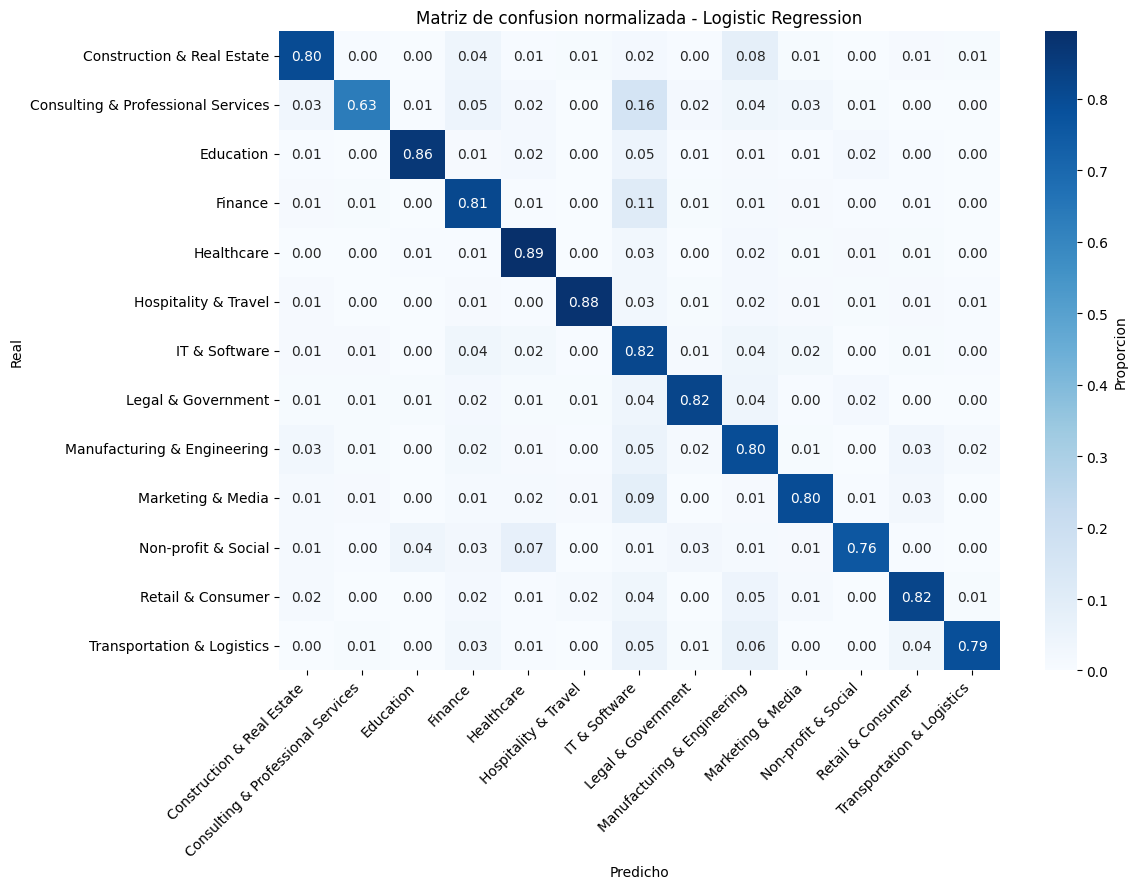

Matriz de confusion guardada


In [14]:
# Cierre Dia 1 - Pipeline completo con LogReg como modelo final
import re, time, os, joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

# Cargar parquet
df_clean = pd.read_parquet("data/processed/jobs_clean.parquet")
print(f"Dataset: {df_clean.shape}")

# Split
X = df_clean["text"]
y = df_clean["macro_category"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Split: train={len(X_train)} test={len(X_test)}")

# Limpieza
def clean_text(t):
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)
print("Limpieza OK")

# TF-IDF
t0 = time.time()
vectorizer = TfidfVectorizer(
    max_features=15000, ngram_range=(1, 2), min_df=5, max_df=0.9,
    stop_words="english", sublinear_tf=True,
)
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)
print(f"TF-IDF: {time.time()-t0:.1f}s")

# LogReg
t0 = time.time()
logreg = LogisticRegression(
    max_iter=200, class_weight="balanced", solver="liblinear", C=1.0,
)
logreg.fit(X_train_vec, y_train)
print(f"LogReg: {time.time()-t0:.1f}s")

# Predicciones y metricas
y_pred_lr = logreg.predict(X_test_vec)
print(f"\n=== Logistic Regression (modelo final) ===")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-macro:    {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1-weighted: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_lr, digits=3))

# Guardar modelos PRIMERO (antes de la grafica, por seguridad)
os.makedirs("models", exist_ok=True)
le = LabelEncoder()
le.fit(y_train)
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")
joblib.dump(logreg, "models/logreg_classifier.pkl")
joblib.dump(le, "models/label_encoder.pkl")
print("\nModelos guardados en models/")

# Matriz de confusion
os.makedirs("reports/figures", exist_ok=True)
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels_sorted, normalize="true")

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=labels_sorted, yticklabels=labels_sorted,
    cbar_kws={"label": "Proporcion"},
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusion normalizada - Logistic Regression")
plt.tight_layout()
plt.savefig("reports/figures/03_confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()
print("Matriz de confusion guardada")

In [15]:
from google.colab import files
files.download("models/tfidf_vectorizer.pkl")
files.download("models/logreg_classifier.pkl")
files.download("models/label_encoder.pkl")
files.download("reports/figures/03_confusion_matrix_logreg.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import lightgbm as lgb
from sklearn.metrics import classification_report, f1_score
import joblib
import time
import pandas as pd

# Load the label encoder
label_encoder = joblib.load("models/label_encoder.pkl")

# Convertir etiquetas de texto a numeros
y_train_num = label_encoder.transform(y_train)
y_test_num = label_encoder.transform(y_test)

# Usamos el wrapper de Scikit-Learn (LGBMClassifier) que sí soporta class_weight='balanced'
model_lgbm = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(label_encoder.classes_),
    n_jobs=-1,
    num_leaves=31,
    min_child_samples=100, # equivalente a min_data_in_leaf
    learning_rate=0.2,
    feature_fraction=0.2,
    bagging_fraction=0.7,
    bagging_freq=1,
    class_weight="balanced",
    max_bin=63,
    n_estimators=200, # equivalente a num_boost_round
    random_state=42
)

start = time.time()
model_lgbm.fit(
    X_train_vec,
    y_train_num,
    eval_set=[(X_test_vec, y_test_num)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=15),
        lgb.log_evaluation(period=10)
    ]
)
print(f"Tiempo: {round(time.time() - start, 1)}s")

# Prediccion y metricas
# Convertir a DataFrame con los nombres correctos del vectorizador
feature_names = vectorizer.get_feature_names_out()
X_test_named = pd.DataFrame.sparse.from_spmatrix(X_test_vec, columns=feature_names)
y_pred = model_lgbm.predict(X_test_named)

print("\n=== LightGBM ===")
print(f"F1-macro:  {f1_score(y_test_num, y_pred, average='macro'):.4f}")
print(f"Accuracy:  {(y_test_num == y_pred).mean():.4f}")
print(classification_report(y_test_num, y_pred, target_names=label_encoder.classes_))

# Serializar
joblib.dump(model_lgbm, "models/lgbm_classifier.pkl")
print("Modelo guardado")

[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.2, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 28.872512 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 929794
[LightGBM] [Info] Number of data points

## Resumen de decisiones hasta este punto

1. **Dataset:** LinkedIn Job Postings (Kaggle, arshkon). Se unió `postings.csv` con `job_industries.csv` e `industries.csv` para obtener la etiqueta de industria por vacante (122.308 filas iniciales).
2. **Etiquetado:** Las 140+ industrias granulares de LinkedIn se agruparon manualmente en 14 macro-categorías afines por perfil de skills. Cobertura del mapeo: 90.7%.
3. **Exclusión de HR & Staffing:** Sus top-tokens (`nurse, rn, careerstaff, patient`) evidencian que son agencias de reclutamiento publicando para terceros sectores. Se descartó por ser ruido de etiquetado, no por bajo volumen.
4. **Limpieza:** Se eliminaron 14.156 duplicados exactos por descripción y 177 vacantes con menos de 30 palabras. Dataset final: 87.910 filas, 13 clases.
5. **Desbalance:** Ratio 14:1 entre clase mayoritaria (Healthcare 23.4%) y minoritaria (Consulting 1.7%). Se maneja con `class_weight='balanced'` y split estratificado 80/20.
6. **Texto:** Se concatenó `title + description`. Limpieza ligera (HTML, URLs, no-alfanuméricos). Se omitió lematización tras verificar separabilidad alta en top-tokens por clase.
7. **Vectorización:** TF-IDF con 15.000 features, n-gramas (1,2), `min_df=5`, `sublinear_tf=True`, stopwords en inglés.
8. **Modelos:** Logistic Regression (solver `liblinear`, baseline) y LightGBM (modelo principal, 400 estimadores, `class_weight='balanced'`).
9. **Decisión sobre SAGA:** Se descartó por no converger en tiempo razonable (>20 min). `liblinear` es funcionalmente equivalente para multiclase con TF-IDF y converge en ~3 min.
10. **Artefactos persistidos:** vectorizador TF-IDF, modelo LightGBM y LabelEncoder serializados en `models/` para uso en el pipeline de Streamlit del Día 3.

# Día 2: Agente Evaluador de CVs con LangChain y Groq

Este notebook implementa el agente de IA encargado de:
1. Leer una hoja de vida en PDF.
2. Compararla contra una vacante específica.
3. Generar un score de compatibilidad y recomendaciones usando Llama-3 (vía Groq).

In [17]:
# 1. Instalación de dependencias necesarias
!pip install pdfplumber langchain langchain-groq python-dotenv -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 58.0 MB/s eta 0:00:00


In [18]:
# 2. Configuración de API Key de Groq
import os
from google.colab import userdata

# En Colab, guarda tu clave en 'Secrets' (icono de llave a la izquierda) con el nombre GROQ_API_KEY
try:
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
    print("API Key cargada correctamente de Secrets.")
except:
    print("ADVERTENCIA: No se encontró GROQ_API_KEY en Secrets. Ingrésala manualmente:")
    from getpass import getpass
    os.environ["GROQ_API_KEY"] = getpass("Groq API Key: ")

API Key cargada correctamente de Secrets.


In [19]:
# 3. Extracción de texto desde PDF
import pdfplumber

def extract_cv_text(pdf_path):
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text += page.extract_text() + "\n"

        if len(text.strip()) < 100:
            return "ERROR: El PDF parece estar vacío o ser una imagen escaneada."
        return text
    except Exception as e:
        return f"ERROR al leer el PDF: {str(e)}"

print("Función de extracción lista.")

Función de extracción lista.


In [36]:
!pip install -U langchain langchain-groq python-dotenv -q

import json
import re
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

EVALUATION_PROMPT = """
Eres un evaluador experto de talento.

Compara la hoja de vida del candidato contra la vacante. Debes evaluar evidencia real
del CV, no asumir habilidades que no aparecen.

Reglas de Puntuación (Score):
- 85-100: Coincidencia excelente. El candidato cumple o excede todos los requisitos clave.
- 70-84: Coincidencia alta. El candidato cumple la mayoría de los requisitos, con algunas áreas de mejora menores.
- 40-69: Coincidencia media. El candidato cumple algunos requisitos, pero hay brechas significativas.
- 0-39: Coincidencia baja. El candidato no cumple los requisitos principales o no tiene la experiencia relevante.

VACANTE:
{job_description}

CV:
{cv_text}

Devuelve unicamente JSON valido con esta estructura:
{{
  "score": 0,
  "resumen_perfil": "resumen breve",
  "fortalezas": ["fortaleza 1", "fortaleza 2", "fortaleza 3"],
  "brechas": ["brecha 1", "brecha 2"],
  "recomendaciones": ["recomendacion 1", "recomendacion 2", "recomendacion 3"]
}}
"""

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)
prompt = ChatPromptTemplate.from_template(EVALUATION_PROMPT)
chain = prompt | llm

def parse_json_response(raw_text):
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if not match:
        raise ValueError("El modelo no devolvio JSON valido.")
    return json.loads(match.group())

def evaluate_candidate(pdf_path, job_description):
    cv_text = extract_cv_text(pdf_path)

    if isinstance(cv_text, str) and cv_text.startswith("ERROR"):
        raise ValueError(cv_text)

    response = chain.invoke({
        "job_description": job_description,
        "cv_text": cv_text[:12000],
    })

    return parse_json_response(response.content)

print("Agente evaluador configurado correctamente.")

Agente evaluador configurado correctamente.


In [37]:
# 5. Generador de CVs sinteticos en PDF con fpdf2
!pip install fpdf2 -q
from fpdf import FPDF
import os

os.makedirs("data/sample_cvs", exist_ok=True)

cvs = {
    "cv_01_senior_dev.pdf": """John Smith - Senior Software Engineer
Experiencia: 6 anos desarrollando aplicaciones con Python, AWS Lambda, microservicios y Docker.
Certificaciones: AWS Solutions Architect Associate.
Proyectos: Migracion de monolito a microservicios para empresa fintech de 500k usuarios.
Habilidades: Python, FastAPI, PostgreSQL, Redis, Docker, Kubernetes, CI/CD con GitHub Actions.""",

    "cv_02_financial_analyst.pdf": """Maria Garcia - Financial Analyst
Experiencia: 4 anos en JP Morgan en analisis de riesgo crediticio y modelado financiero.
Certificaciones: CFA Level 1 aprobado. Excel avanzado, SQL, Python basico.
Educacion: MBA Finance, Universidad de los Andes.""",

    "cv_03_nurse.pdf": """Ana Torres - Registered Nurse
Licencia RN activa en estado de California. 5 anos en UCI de hospital universitario.
Certificaciones: BLS, ACLS, CCRN. Experiencia con ventilacion mecanica y monitoreo hemodinamico.""",

    "cv_04_marketing_manager.pdf": """Carlos Lopez - Marketing Manager
5 anos gestionando campanas digitales con Google Ads, Meta Ads y TikTok Ads.
Experiencia en SEO tecnico, Google Analytics 4, y CRO. Presupuestos manejados: hasta USD 200k/mes.""",

    "cv_05_civil_engineer.pdf": """Pedro Ramirez - Civil Engineer
PMP certificado. 7 anos en obras civiles de infraestructura vial y edificaciones.
Manejo de AutoCAD, S10, presupuestos y cronogramas. Proyectos hasta USD 5M.""",

    "cv_06_junior_analyst.pdf": """Laura Mendez - Data Analyst Junior
1 ano de experiencia en analisis de datos con Excel, Power BI y Python basico.
Proyectos universitarios: analisis exploratorio del dataset Titanic con Pandas.
Educacion: Recien graduada de Ingenieria Industrial.""",

    "cv_07_teacher.pdf": """Roberto Silva - Profesor Universitario
8 anos ensenando matematicas y estadistica en universidad publica.
Conocimientos basicos de Python para estadistica. Sin experiencia en cloud ni ingenieria de datos.""",

    "cv_08_accountant.pdf": """Sofia Castro - Contadora Publica
3 anos en firma de auditoria realizando cierres contables y declaraciones de renta.
Manejo de SAP FI y Excel. Sin experiencia en banca de inversion ni modelos de valoracion.""",

    "cv_09_graphic_designer.pdf": """Diego Mora - Disenador Grafico
5 anos creando piezas graficas para redes sociales. Manejo de Adobe Illustrator, Photoshop, Figma.
Sin experiencia en SEO, SEM ni analisis de datos de campanas.""",

    "cv_10_logistics.pdf": """Valentina Rios - Coordinadora Logistica
3 anos coordinando envios internacionales y gestion de proveedores.
Sin certificacion Lean Six Sigma ni experiencia en planta de manufactura.""",

    "cv_11_chef.pdf": """Marco Fernandez - Chef Ejecutivo
15 anos de experiencia en cocina francesa y gestion de restaurantes de alta cocina.
Sin ninguna experiencia en programacion, tecnologia o software.""",

    "cv_12_history_grad.pdf": """Isabella Vargas - Licenciada en Historia
Recien graduada con tesis sobre historia economica colonial. Manejo basico de Word y Excel.
Sin experiencia financiera ni conocimientos de CFA o Bloomberg.""",

    "cv_13_retail_seller.pdf": """Miguel Herrera - Vendedor de Tienda
3 anos vendiendo electrodomesticos en tienda retail. Atencion al cliente y manejo de caja.
Sin experiencia tecnica en tecnologia, cloud ni programacion.""",

    "cv_14_general_doctor.pdf": """Dra. Camila Ortiz - Medico General
5 anos en consulta externa y urgencias. Especialista en medicina interna.
Sin formacion juridica ni experiencia en derecho corporativo o contratos.""",

    "cv_15_freshman.pdf": """Luis Perez - Estudiante Universitario
Cursando primer semestre de Administracion de Empresas. Sin experiencia laboral formal.
Actividades: representante estudiantil del salon.""",
}

def create_cv_pdf(filename, content):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Helvetica", size=11)
    pdf.set_margins(20, 20, 20)
    # Calculate available width: Page width - left margin - right margin
    available_width = pdf.w - pdf.l_margin - pdf.r_margin
    for line in content.strip().split("\n"):
        pdf.multi_cell(available_width, 8, line.strip()) # Use explicit width
    pdf.output(f"data/sample_cvs/{filename}")

for filename, content in cvs.items():
    create_cv_pdf(filename, content)
    print(f"Creado: {filename}")

print("\nTodos los CVs generados.")

Creado: cv_01_senior_dev.pdf
Creado: cv_02_financial_analyst.pdf
Creado: cv_03_nurse.pdf
Creado: cv_04_marketing_manager.pdf
Creado: cv_05_civil_engineer.pdf
Creado: cv_06_junior_analyst.pdf
Creado: cv_07_teacher.pdf
Creado: cv_08_accountant.pdf
Creado: cv_09_graphic_designer.pdf
Creado: cv_10_logistics.pdf
Creado: cv_11_chef.pdf
Creado: cv_12_history_grad.pdf
Creado: cv_13_retail_seller.pdf
Creado: cv_14_general_doctor.pdf
Creado: cv_15_freshman.pdf

Todos los CVs generados.


In [39]:
# 5. Ejemplo de prueba rapida (requiere PDF)
test_job = """
Senior Data Scientist.
Requisitos: 5 anos de experiencia en Python, SQL, y modelos de Machine Learning en produccion.
Deseable: Experiencia con LLMs y LangChain.
"""

# Usa un PDF real en data/sample_cvs/
test_pdf = "data/sample_cvs/cv_06_junior_analyst.pdf"

# Descomenta la linea de abajo para probar (requiere API Key y PDF generado)
# print(evaluate_candidate(test_pdf, test_job))

In [38]:
import os
import time
import pandas as pd

test_cases = [
    {
        "id": 1,
        "expected_level": "alto",
        "pdf_path": "data/sample_cvs/cv_01_senior_dev.pdf",
        "job": "Senior Software Engineer. Requisitos: 6 anos Python, AWS, microservicios, Docker. Deseable: Kubernetes, CI/CD."
    },
    {
        "id": 2,
        "expected_level": "alto",
        "pdf_path": "data/sample_cvs/cv_02_financial_analyst.pdf",
        "job": "Financial Analyst. Requisitos: CFA nivel 1, 4 anos en banca, Excel avanzado, SQL. Deseable: Python para analisis."
    },
    {
        "id": 3,
        "expected_level": "alto",
        "pdf_path": "data/sample_cvs/cv_03_nurse.pdf",
        "job": "Registered Nurse (RN) ICU. Requisitos: Licencia RN, 5 anos en UCI. Certificaciones: BLS, ACLS. Manejo de ventilacion."
    },
    {
        "id": 4,
        "expected_level": "alto",
        "pdf_path": "data/sample_cvs/cv_04_marketing_manager.pdf",
        "job": "Marketing Manager Digital. Requisitos: 5 anos en campanas digitales (Google, Meta, TikTok Ads), SEO, GA4. Presupuesto > $100k."
    },
    {
        "id": 5,
        "expected_level": "alto",
        "pdf_path": "data/sample_cvs/cv_05_civil_engineer.pdf",
        "job": "Ingeniero Civil PMP. Requisitos: PMP, 7 anos en obras civiles (vias, edificaciones). Manejo de AutoCAD, S10."
    },
    {
        "id": 6,
        "expected_level": "medio",
        "pdf_path": "data/sample_cvs/cv_06_junior_analyst.pdf",
        "job": "Data Analyst. Requisitos: Python, SQL, Power BI. Experiencia en analisis de datos."
    },
    {
        "id": 7,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_07_teacher.pdf",
        "job": "Profesor de Estadistica con Python. Requisitos: 5 anos ensenando estadistica. Manejo de Python para analisis."
    },
    {
        "id": 8,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_08_accountant.pdf",
        "job": "Contador Senior con SAP FI. Requisitos: 5 anos en auditoria, cierres contables. Manejo de SAP FI y Excel avanzado."
    },
    {
        "id": 9,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_09_graphic_designer.pdf",
        "job": "Disenador UX/UI con Figma. Requisitos: 3 anos en diseno UX/UI, prototipado con Figma. Experiencia con Design Systems."
    },
    {
        "id": 10,
        "expected_level": "medio",
        "pdf_path": "data/sample_cvs/cv_10_logistics.pdf",
        "job": "Coordinador Logistico Lean Six Sigma. Requisitos: 3 anos en logistica, gestion de proveedores. Certificacion Lean Six Sigma."
    },
    {
        "id": 11,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_11_chef.pdf",
        "job": "Gerente de Restaurant. Requisitos: 5 anos gestionando personal, P&L. Experiencia en servicio al cliente."
    },
    {
        "id": 12,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_12_history_grad.pdf",
        "job": "Analista Financiero Junior. Requisitos: Excel, Power BI. Conocimientos basicos de mercados financieros."
    },
    {
        "id": 13,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_13_retail_seller.pdf",
        "job": "Sales Representative de Software. Requisitos: 2 anos en ventas B2B de software. Manejo de CRM (Salesforce)."
    },
    {
        "id": 14,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_14_general_doctor.pdf",
        "job": "Abogado Junior. Requisitos: Recien graduado, conocimientos de derecho corporativo. Manejo de contratos."
    },
    {
        "id": 15,
        "expected_level": "bajo",
        "pdf_path": "data/sample_cvs/cv_15_freshman.pdf",
        "job": "Manufacturing Plant Manager. Requisitos: 10 anos en gestion de planta, P&L, liderazgo de 50+ personas."
    }
]

def score_to_level(score):
    if score >= 70:
        return "alto"
    elif score >= 40:
        return "medio"
    return "bajo"

results = []
for case in test_cases:
    print(f"\nEvaluando caso {case['id']} (esperado: {case['expected_level']})...")
    start = time.time()
    try:
        output = evaluate_candidate(case["pdf_path"], case["job"])
        score = output.get("score", -1) if isinstance(output, dict) else -1
        predicted_level = score_to_level(score) if score >= 0 else "error"
        acerto = predicted_level == case["expected_level"]
        results.append({
            "cv_id": case["id"],
            "expected_level": case["expected_level"],
            "score": score,
            "predicted_level": predicted_level,
            "acerto": acerto,
            "latency_sec": round(time.time() - start, 2),
            "fortalezas": str(output.get("fortalezas", [])) if isinstance(output, dict) else "",
            "brechas": str(output.get("brechas", [])) if isinstance(output, dict) else "",
            "recomendaciones": str(output.get("recomendaciones", [])) if isinstance(output, dict) else "",
        })
        print(f"  Score: {score} | Nivel: {predicted_level} | Acerto: {acerto}")
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append({
            "cv_id": case["id"],
            "expected_level": case["expected_level"],
            "score": -1,
            "predicted_level": "error",
            "acerto": False,
            "latency_sec": round(time.time() - start, 2),
        })

df_results = pd.DataFrame(results)
tasa_acierto = df_results["acerto"].mean()
print(f"\nTasa de acierto: {tasa_acierto:.1%} ({df_results['acerto'].sum()}/15)")
print(f"Latencia promedio: {df_results['latency_sec'].mean():.1f}s")

os.makedirs('evaluation', exist_ok=True)
print(f"Directory 'evaluation' exists: {os.path.isdir('evaluation')}")
df_results.to_csv("evaluation/agent_results.csv", index=False)
print("Resultados guardados en evaluation/agent_results.csv")


Evaluando caso 1 (esperado: alto)...
  Score: 95 | Nivel: alto | Acerto: True

Evaluando caso 2 (esperado: alto)...
  Score: 95 | Nivel: alto | Acerto: True

Evaluando caso 3 (esperado: alto)...
  Score: 100 | Nivel: alto | Acerto: True

Evaluando caso 4 (esperado: alto)...
  Score: 95 | Nivel: alto | Acerto: True

Evaluando caso 5 (esperado: alto)...
  Score: 95 | Nivel: alto | Acerto: True

Evaluando caso 6 (esperado: medio)...
  Score: 60 | Nivel: medio | Acerto: True

Evaluando caso 7 (esperado: bajo)...
  Score: 85 | Nivel: alto | Acerto: False

Evaluando caso 8 (esperado: bajo)...
  Score: 55 | Nivel: medio | Acerto: False

Evaluando caso 9 (esperado: bajo)...
  Score: 40 | Nivel: medio | Acerto: False

Evaluando caso 10 (esperado: medio)...
  Score: 70 | Nivel: alto | Acerto: False

Evaluando caso 11 (esperado: bajo)...
  Score: 40 | Nivel: medio | Acerto: False

Evaluando caso 12 (esperado: bajo)...
  Score: 20 | Nivel: bajo | Acerto: True

Evaluando caso 13 (esperado: bajo)..

In [ ]:
# Exportar artefactos del proyecto para usar localmente
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

artifact_paths = [
    "models/tfidf_vectorizer.pkl",
    "models/logreg_classifier.pkl",
    "models/lgbm_classifier.pkl",
    "models/label_encoder.pkl",
    "data/processed/jobs_clean.parquet",
    "evaluation/agent_results.csv",
]

artifact_dirs = [
    "reports/figures",
    "data/sample_cvs",
]

zip_path = Path("proyecto_empleo_ia_artifacts.zip")
with ZipFile(zip_path, "w", ZIP_DEFLATED) as zip_file:
    for path_text in artifact_paths:
        path = Path(path_text)
        if path.exists():
            zip_file.write(path, path.as_posix())
            print(f"Incluido: {path}")
        else:
            print(f"No encontrado: {path}")

    for dir_text in artifact_dirs:
        directory = Path(dir_text)
        if directory.exists():
            for path in directory.rglob("*"):
                if path.is_file():
                    zip_file.write(path, path.as_posix())
                    print(f"Incluido: {path}")
        else:
            print(f"No encontrado: {directory}")

print(f"ZIP creado: {zip_path}")
files.download(str(zip_path))